In [1]:
## Importing necessary libraries & all Machine Learning models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, # Classification
    mean_absolute_error, mean_squared_error, r2_score        # Regression
)
import streamlit as st
import joblib
import warnings

warnings.filterwarnings("ignore")


In [ ]:
life=pd.read_csv('Life Expectancy Data.csv')
life.head()

In [ ]:
life.describe().T

In [ ]:
## Count Missing in Colomns as %age
life.isnull().sum()/life.shape[0]*100

In [ ]:
## selecting only colomns with Missing values
missing_cols = life.isnull().sum()
missing_cols = missing_cols[missing_cols > 0].to_dict()
print(missing_cols)


In [ ]:
# check skewness & distribution of missing colomns one by one
for col in missing_cols.keys():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(life[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=life[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in missing_cols.keys():
    skewness = life[col].skew()
    
    if abs(skewness) < 0.5:
        # Approximately normal → use Mean
        life[col] = life[col].fillna(life[col].mean())
        print(f"{col}: Mean imputation (skew={skewness:.2f})")
    else:
        # Skewed → use Median
        life[col] = life[col].fillna(life[col].median())
        print(f"{col}: Median imputation (skew={skewness:.2f})")

In [ ]:
## Rechecking Missing values after imputation
life.isnull().sum()/life.shape[0]*100

## Step 1: Duplicate Row Check

In [ ]:
## 1. Duplicate Row Check
print('Total rows:', life.shape[0])
print('Duplicate rows:', life.duplicated().sum())
print()
# Check duplicates on Country + Year (should be unique per country per year)
dup_country_year = life.duplicated(subset=['Country', 'Year']).sum()
print(f'Duplicate Country-Year combinations: {dup_country_year}')
if dup_country_year > 0:
    life = life.drop_duplicates(subset=['Country', 'Year'])
    print('Duplicates removed.')
else:
    print('No duplicates found. Dataset is clean.')


## Step 2: Target Variable Analysis

In [ ]:
## 2. Target Variable Analysis — 'Life expectancy'
target_col = 'Life expectancy '

print(life[target_col].describe())
print(f'\nSkewness: {life[target_col].skew():.3f}')
print(f'Kurtosis: {life[target_col].kurt():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
sns.histplot(life[target_col], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Life Expectancy')

# Boxplot
sns.boxplot(x=life[target_col], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Life Expectancy')

# QQ Plot to check normality
from scipy import stats
stats.probplot(life[target_col].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot of Life Expectancy')

plt.tight_layout()
plt.show()


## Step 3: Univariate Analysis — All Numeric Features

In [ ]:
## 3. Univariate Analysis — All Numeric Features
numeric_cols = life.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}):', numeric_cols)

# Skewness summary
skew_df = life[numeric_cols].skew().reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['AbsSkew'] = skew_df['Skewness'].abs()
skew_df = skew_df.sort_values('AbsSkew', ascending=False)
print('\nSkewness of all numeric features:')
print(skew_df.to_string(index=False))

# Plot distributions for all numeric columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(life[col], kde=True, ax=axes[i], color='mediumseagreen')
    axes[i].set_title(f'{col}\n(skew={life[col].skew():.2f})')
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions of All Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Step 4: Outlier Detection & Treatment

In [ ]:
## 4. Outlier Detection & Treatment (IQR-based Capping)

# Columns to skip for outlier treatment (ID-like or target)
skip_cols = ['Year', 'Life expectancy ']
outlier_cols = [c for c in numeric_cols if c not in skip_cols]

outlier_summary = []
for col in outlier_cols:
    Q1 = life[col].quantile(0.25)
    Q3 = life[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((life[col] < lower) | (life[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Lower Bound': lower, 'Upper Bound': upper, 'Outliers': n_outliers})

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)
print('Outlier Summary (IQR method):')
print(outlier_df[outlier_df['Outliers'] > 0].to_string(index=False))

# Cap outliers (Winsorization)
life_clean = life.copy()
for col in outlier_cols:
    Q1 = life_clean[col].quantile(0.25)
    Q3 = life_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    life_clean[col] = life_clean[col].clip(lower=lower, upper=upper)

print('\nOutlier capping (Winsorization) applied to all numeric features.')
print('Shape after cleaning:', life_clean.shape)

# Visualize boxplots after treatment for top outlier columns
top_outlier_cols = outlier_df[outlier_df['Outliers'] > 0]['Feature'].tolist()[:8]
fig, axes = plt.subplots(2, len(top_outlier_cols), figsize=(20, 8))
for i, col in enumerate(top_outlier_cols):
    sns.boxplot(x=life[col], ax=axes[0][i], color='lightcoral')
    axes[0][i].set_title(f'{col}\n(Before)')
    sns.boxplot(x=life_clean[col], ax=axes[1][i], color='lightgreen')
    axes[1][i].set_title(f'{col}\n(After Capping)')
plt.suptitle('Outlier Treatment: Before vs After', fontsize=14)
plt.tight_layout()
plt.show()


## Step 5: Categorical Encoding

In [ ]:
## 5. Categorical Encoding

cat_cols = life_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
for col in cat_cols:
    print(f'  {col}: {life_clean[col].nunique()} unique values -> {life_clean[col].unique()[:5]}')

# 'Status' → binary encode (Developed=1, Developing=0)
life_clean['Status'] = life_clean['Status'].map({'Developed': 1, 'Developing': 0})
print('\nStatus encoded: Developed=1, Developing=0')

# 'Country' → drop (193 unique values, high cardinality; 
#  country-level variation already captured by other numeric features)
life_clean = life_clean.drop(columns=['Country'])
print("Country column dropped (high cardinality — 193 unique values).")

print('\nShape after encoding:', life_clean.shape)
print('\nData types after encoding:')
print(life_clean.dtypes)


## Step 6: Correlation Heatmap & Multicollinearity Check

In [ ]:
## 6. Correlation Heatmap & Multicollinearity Check

plt.figure(figsize=(18, 14))
corr_matrix = life_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=15)
plt.tight_layout()
plt.show()

# Correlation with Target
target_corr = corr_matrix['Life expectancy '].drop('Life expectancy ').sort_values(key=abs, ascending=False)
print('\nCorrelation with Life Expectancy (sorted by strength):')
print(target_corr.to_string())

# Flag highly correlated feature pairs (potential multicollinearity)
print('\n--- Highly Correlated Feature Pairs (|r| > 0.85) ---')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f'  {pair[0]}  <-->  {pair[1]}  :  r = {pair[2]}')
else:
    print('  No highly correlated pairs found.')


## Step 7: Feature vs Target Relationship (Bivariate Analysis)

In [ ]:
## 7. Feature vs Target — Scatter Plots (Top Correlated Features)

top_features = target_corr.head(10).index.tolist()
print('Top 10 correlated features with Life Expectancy:', top_features)

n_cols = 5
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(life_clean[col], life_clean['Life expectancy '], alpha=0.3, color='steelblue', s=10)
    # Fit a trend line
    m, b = np.polyfit(life_clean[col].dropna(), life_clean.loc[life_clean[col].notna(), 'Life expectancy '], 1)
    x_line = np.linspace(life_clean[col].min(), life_clean[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    r = life_clean[[col, 'Life expectancy ']].corr().iloc[0, 1]
    axes[i].set_title(f'{col}\n(r={r:.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Life Expectancy')

plt.suptitle('Top Features vs Life Expectancy (with trend line)', fontsize=15)
plt.tight_layout()
plt.show()

# Developed vs Developing — Boxplot comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x='Status', y='Life expectancy ', data=life_clean, palette='Set2')
plt.xticks([0, 1], ['Developing', 'Developed'])
plt.title('Life Expectancy: Developed vs Developing Countries')
plt.tight_layout()
plt.show()


## Step 8: Define Features/Target & Train-Test Split

In [ ]:
life_clean.rename(columns={'Life expectancy ': 'Life_expectancy'}, inplace=True)
print('Column renamed: Life expectancy  --> Life_expectancy')
print('Final columns:', life_clean.columns.tolist())
print('Final shape:', life_clean.shape)

In [ ]:
## 8. Define X, y and Train-Test Split

target = 'Life_expectancy'
X = life_clean.drop(columns=[target])
y = life_clean[target]

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeatures used for modelling:')
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nTrain size: {X_train.shape[0]} rows ({X_train.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Test size:  {X_test.shape[0]} rows ({X_test.shape[0]/X.shape[0]*100:.1f}%)')


## Step 9: Feature Scaling

In [ ]:
## 9. Feature Scaling (StandardScaler — fit on train, transform both)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train to avoid data leakage
X_test_scaled  = scaler.transform(X_test)         # transform test using train's parameters

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('Scaling complete — StandardScaler applied.')
print('Train scaled shape:', X_train_scaled.shape)
print('Test  scaled shape:', X_test_scaled.shape)
print('\nSample scaled values (first 3 rows of X_train_scaled):')
print(X_train_scaled.head(3).round(3).to_string())

print('\n✅ EDA Complete! Data is ready for Supervised ML Modelling.')
print('Use X_train_scaled, X_test_scaled, y_train, y_test for modelling.')


In [ ]:
# Define models in a dictionary for easy iteration
from sklearn.linear_model import ElasticNet
models = {
    "linear": LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    "Elastic_Net":ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results_list = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on both sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate R² for both
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    results_list.append({
        'Model': name,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'R² Gap': r2_train - r2_test, # High gap indicates overfitting
    })

# Convert to DataFrame and Sort
results_df = pd.DataFrame(results_list).sort_values('Test R²', ascending=False)
print(results_df)

In [ ]:
## Gridsearh cv
from sklearn.model_selection import GridSearchCV
# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2')
rf_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
rf_best =rf_grid.best_params_


In [ ]:
# Hyperparameter tuning for Linear Models (Ridge, Lasso, ElasticNet)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
Ridge_params = {'alpha': [0.1, 1.0, 10.0]}
Lasso_params = {'alpha': [0.01, 0.1, 1.0]}
ElasticNet_params = {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}
ridge_grid = GridSearchCV(Ridge(), Ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)
lasso_grid = GridSearchCV(Lasso(), Lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)
elastic_grid = GridSearchCV(ElasticNet(), ElasticNet_params, cv=5, scoring='r2')
elastic_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
ridge_best = ridge_grid.best_params_
lasso_best = lasso_grid.best_params_
elastic_best = elastic_grid.best_params_

In [ ]:
# Hyperparameter tuning for Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt_params = {
    'criterion': ['mse', 'friedman_mse', 'mae'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='r2')
dt_grid.fit(X_train_scaled, y_train)    
## Best parameters and score dictionary
dt_best = dt_grid.best_params_

In [ ]:
# Hyperparameter tuning for SVR
from sklearn.svm import SVR
svr_params = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 10, 100],
    'gamma': ['scale', 'auto']
}  
svr_grid = GridSearchCV(SVR(), svr_params, cv=5, scoring='r2')
svr_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
svr_best = svr_grid.best_params_


In [ ]:
# Hyperparameter tuning for Voting Regressor (Ensemble of top models)
from sklearn.ensemble import VotingRegressor

# Define your two potential sets of estimators
set_1 = [('ridge', Ridge(**ridge_best)), ('lasso', Lasso(**lasso_best)), ('elastic', ElasticNet(**elastic_best))]
set_2 = [('rf', RandomForestRegressor(**rf_best, random_state=42)), ('dt', DecisionTreeRegressor(**dt_best, random_state=42)), ('svr', SVR(**svr_best))]

# The param_grid should map to the 'estimators' argument
voting_params = {
    'estimators': [set_1, set_2],
   
}


voting_grid = GridSearchCV(
    VotingRegressor(estimators=set_1), 
    param_grid=voting_params, 
    cv=5, 
    scoring='r2'
)

voting_grid.fit(X_train_scaled, y_train)

best_ensemble = voting_grid.best_params_


In [ ]:
# Hyperparameter tuning for Bagging Regressor
from sklearn.ensemble import BaggingRegressor 
bagging_params = {
    'estimator': [DecisionTreeRegressor(**dt_best, random_state=42)],
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0]
}
bagging_grid = GridSearchCV(BaggingRegressor(), bagging_params, cv=5, scoring='r2')
bagging_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
bagging_best = bagging_grid.best_params_

In [ ]:
# Hyperparameter tuning for AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor
ada_params = {
    'estimator': [DecisionTreeRegressor(**dt_best, random_state=42)],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}
ada_grid = GridSearchCV(AdaBoostRegressor(), ada_params, cv=5, scoring='r2')
ada_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
ada_best = ada_grid.best_params_


In [ ]:
# Hyperparameter tuning for XG Boost Regressor
from xgboost import XGBRegressor
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=5, scoring='r2')
xgb_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
xgb_best = xgb_grid.best_params_
# Hyperparameter tuning for LightGBM Regressor
from lightgbm import LGBMRegressor
lgbm_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}
lgbm_grid = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1, importance_type='split'), lgbm_params, cv=5, scoring='r2')
lgbm_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
lgbm_best = lgbm_grid.best_params_


In [ ]:
# Hyperparameter tuning for Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=5, scoring='r2')
gb_grid.fit(X_train_scaled, y_train)
## Best parameters and score dictionary
gb_best = gb_grid.best_params_


In [ ]:
# Define models after Hyperparameter Tuning
models = {
    "linear": LinearRegression(),
    'Ridge': Ridge(**ridge_best),
    'Lasso': Lasso(**lasso_best),
    "Elastic_Net":ElasticNet(**elastic_best),
    'Random Forest': RandomForestRegressor(**rf_best, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(**gb_best, random_state=42),
    'SVR': SVR(**svr_best),
    'XGBoost': XGBRegressor(**xgb_best, random_state=42),
    'LightGBM': LGBMRegressor(**lgbm_best, random_state=42,verbose=-1,importance_type='split')
}
results_list = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on both sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate R² for both
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    results_list.append({
        'Model': name,
        'Train R²': r2_train*100,
        'Test R²': r2_test*100,
        'R² Gap': (r2_train - r2_test)*100, # High gap indicates overfitting
        'MAE (Test)': mean_absolute_error(y_test, y_test_pred),
        'MSE (Test)': mean_squared_error(y_test, y_test_pred)
    })

# Convert to DataFrame and Sort
results_df = pd.DataFrame(results_list).sort_values('Test R²', ascending=False)
print(results_df)

In [ ]:
## Adjusted R² Calculation for the best model

# 1. Get the number of observations (n) and features (k)
n_train = X_train_scaled.shape[0]
n_test = X_test_scaled.shape[0]
k = X_train_scaled.shape[1]

results_list = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # 2. Calculate Adjusted R²
    adj_r2_train = 1 - ((1 - r2_train) * (n_train - 1) / (n_train - k - 1))
    adj_r2_test = 1 - ((1 - r2_test) * (n_test - 1) / (n_test - k - 1))
    
    results_list.append({
        'Model': name,
        'Train R²': r2_train * 100,
        'Test R²': r2_test * 100,
        'Adj Train R²': adj_r2_train * 100,
        'Adj Test R²': adj_r2_test * 100,
        'R² Gap': (r2_train - r2_test) * 100,
        'Adj R² Gap': (adj_r2_train - adj_r2_test) * 100,
        'MAE (Test)': mean_absolute_error(y_test, y_test_pred),
        'MSE (Test)': mean_squared_error(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results_list).sort_values('Adj Test R²', ascending=False)


In [ ]:
results_df

In [ ]:
# 1. Get the number of observations (n) and features (k)
n_train = X_train_scaled.shape[0]
n_test = X_test_scaled.shape[0]
k = X_train_scaled.shape[1]

results_list = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # 2. Calculate Adjusted R²
    adj_r2_train = 1 - ((1 - r2_train) * (n_train - 1) / (n_train - k - 1))
    adj_r2_test = 1 - ((1 - r2_test) * (n_test - 1) / (n_test - k - 1))
    
    results_list.append({
        'Model': name,
        'Train R²': r2_train * 100,
        'Test R²': r2_test * 100,
        'Adj Train R²': adj_r2_train * 100,
        'Adj Test R²': adj_r2_test * 100,
        'R² Gap': (r2_train - r2_test) * 100,
        'Adj R² Gap': (adj_r2_train - adj_r2_test) * 100,
        'MAE (Test)': mean_absolute_error(y_test, y_test_pred),
        'MSE (Test)': mean_squared_error(y_test, y_test_pred)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results_list).sort_values('Adj Test R²', ascending=False)


# --- SAVE THE BEST MODEL ---

# 3. Identify the best model name from the DataFrame (top row)
best_model_name = results_df.iloc[0]['Model']
best_model_object = models[best_model_name]

# 4. Save to a file
model_filename = f'best_{best_model_name.lower().replace(" ", "_")}_model.pkl'
joblib.dump(best_model_object, model_filename)
print(f"\nSaved the best model ({best_model_name}) to {model_filename}")

# --- LOAD THE MODEL (for future use) ---

# 5. Load the model back
loaded_model = joblib.load(model_filename)

# 6. Verify it works by making a prediction
# new_prediction = loaded_model.predict(X_test_scaled[:5]) 
# print(new_prediction)

In [2]:
## Second_Projects
income_project=pd.read_csv("income_evaluation.csv")
income_project.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
## Descriptive statistics of the dataset
income_project.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [4]:
## Checking Missing values in the dataset
income_project.isna().sum()


age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

In [5]:
## Taregt Variable Analysis
income_project.columns = income_project.columns.str.strip()  # remove leading/trailing spaces
target_col = "income"
print(income_project[target_col].value_counts())
print(income_project[target_col].value_counts(normalize=True) * 100)





income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


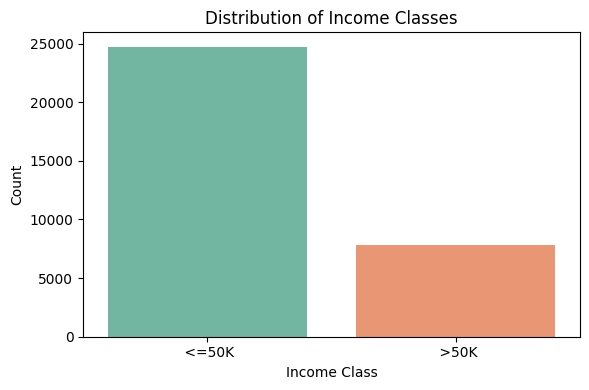

In [6]:
## Chances of Class Imbalance in the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=income_project, palette='Set2')
plt.title('Distribution of Income Classes')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

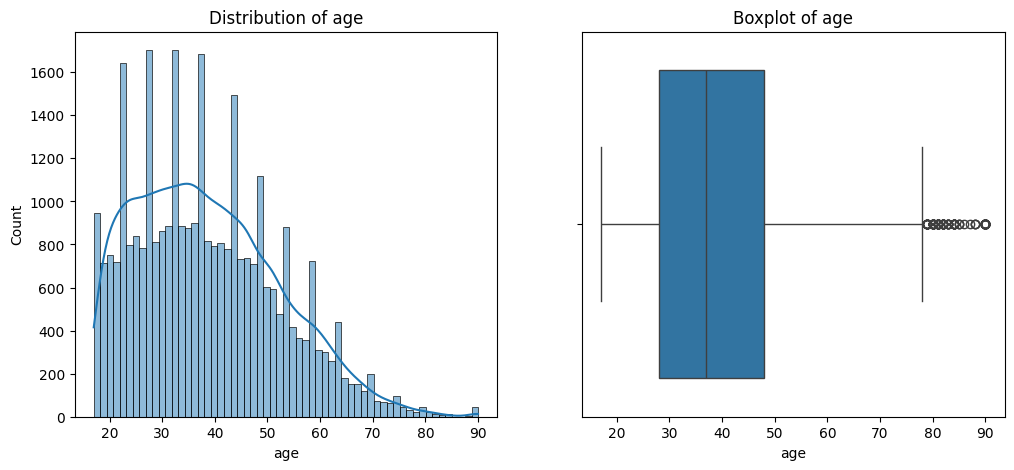

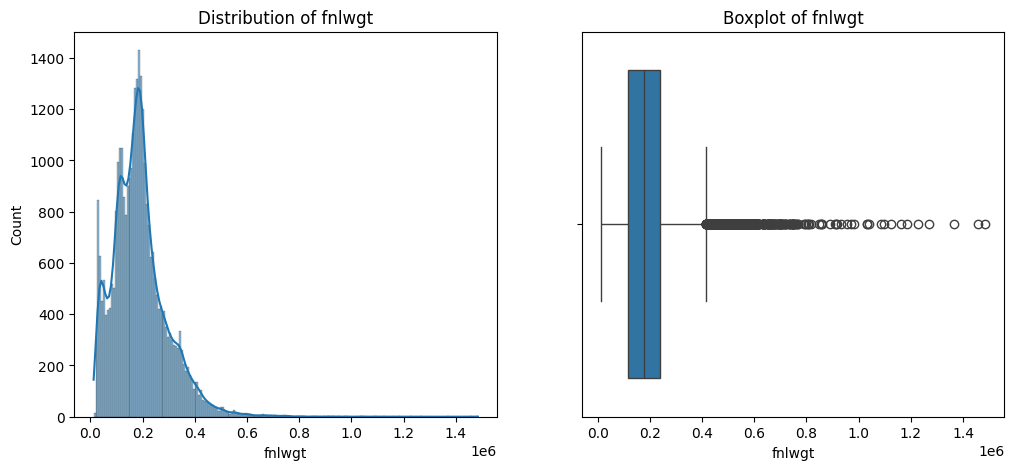

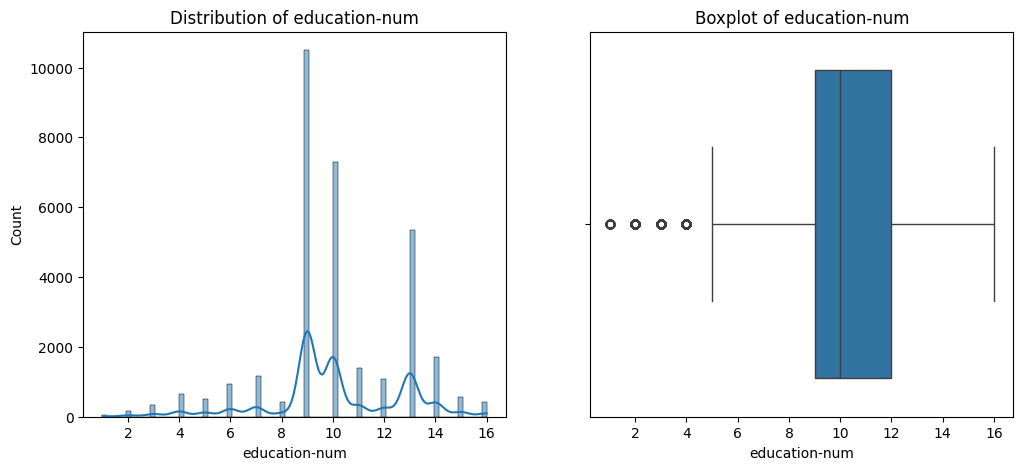

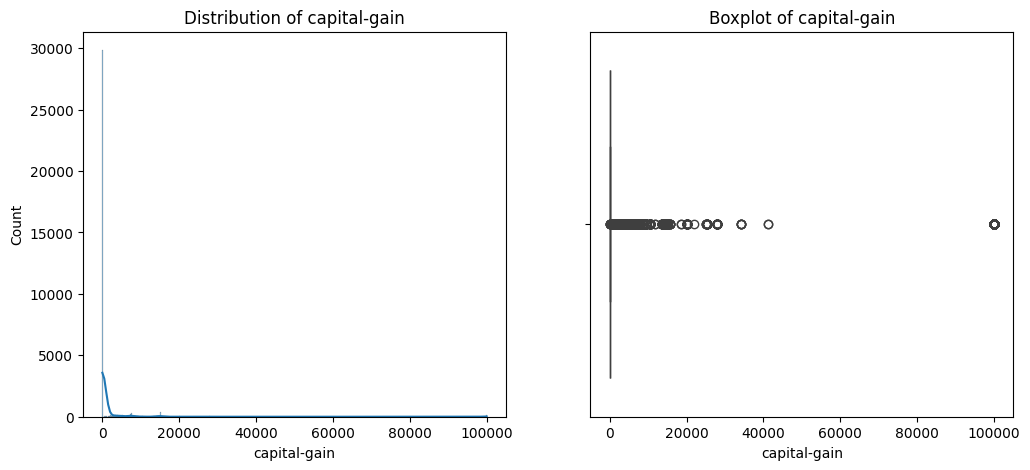

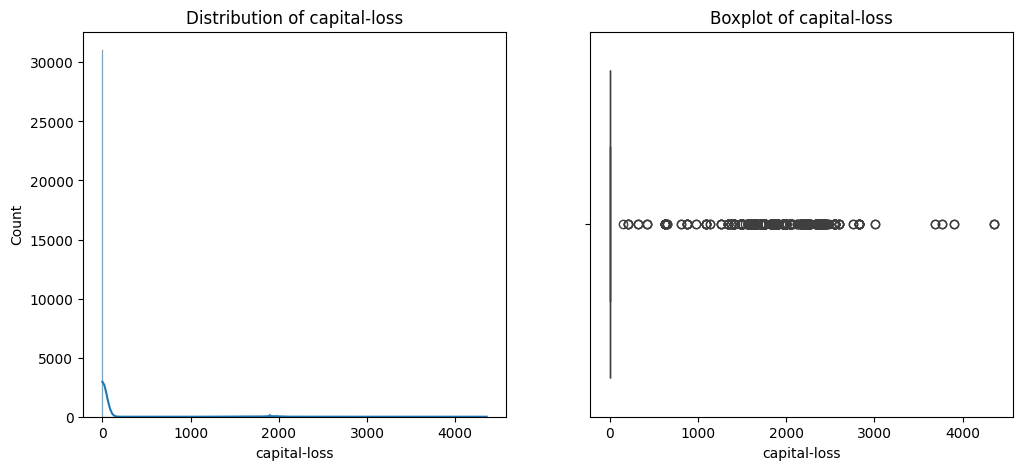

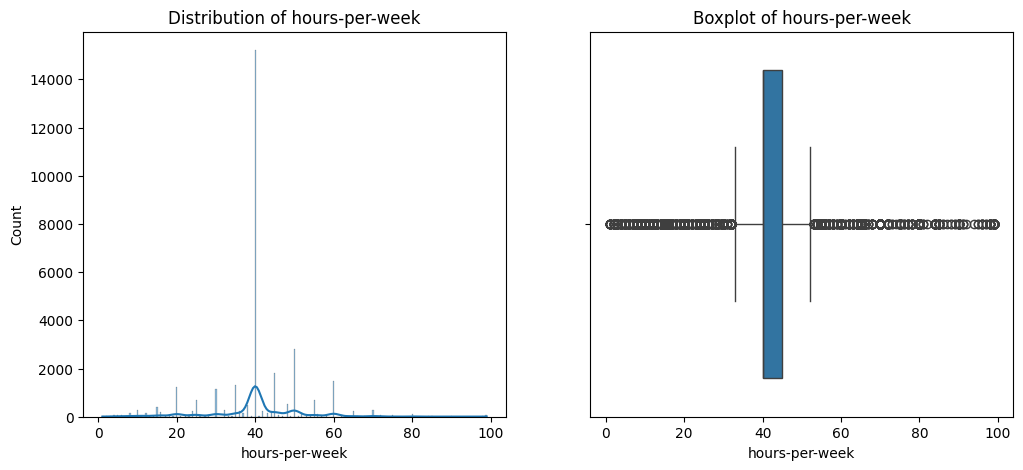

In [7]:
## Univariate Analysis of Numeric Features
numeric_cols = income_project.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(income_project[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=income_project[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [8]:
## Drop Inrelevant Columns (if any)
income_project = income_project.drop(columns=['fnlwgt'])  # 'fnlwgt' is a sampling weight, not a predictive feature
print('Columns after dropping irrelevant ones:', income_project.columns.tolist())


Columns after dropping irrelevant ones: ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [9]:
## Striping leading/trailing spaces from column names and categorical values
income_project.columns = income_project.columns.str.strip()
for col in income_project.select_dtypes(include='object').columns:
    income_project[col] = income_project[col].str.strip()
print('Column names after stripping spaces:', income_project.columns.tolist())
## Categorical Encoding
cat_cols = income_project.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
for col in cat_cols:
    print(f'  {col}: {income_project[col].nunique()} unique values -> {income_project[col].unique()[:5]}')
# 'income' → binary encode (<=50K=0, >50K=1)
income_project['income'] = income_project['income'].map({'<=50K': 0, '>50K': 1})
print('\nIncome encoded: <=50K=0, >50K=1')
# One-Hot Encode other categorical variables
income_project = pd.get_dummies(income_project, columns=[col for col in cat_cols if col != 'income'], drop_first=True)
print('One-Hot Encoding applied to categorical features (except target).') 
print('Shape after encoding:', income_project.shape)
print('Columns after encoding:', income_project.columns.tolist())

Column names after stripping spaces: ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
  workclass: 9 unique values -> ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov']
  education: 16 unique values -> ['Bachelors' 'HS-grad' '11th' 'Masters' '9th']
  marital-status: 7 unique values -> ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated']
  occupation: 15 unique values -> ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service']
  relationship: 6 unique values -> ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried']
  race: 5 unique values -> ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
  sex: 2 unique

In [10]:
income_project.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [11]:
## Feature Scaling (StandardScaler)

scaler = StandardScaler()
numeric_cols = income_project.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('income')  # Exclude target from scaling
income_project[numeric_cols] = scaler.fit_transform(income_project[numeric_cols])

income_project.head()
## Define X, y and Train-Test Split

target = 'income'
X = income_project.drop(columns=[target])
y = income_project[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
## Run All Supervised ML Models (Classification) without GridSearchCV  [OPTIMISED]
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# n_jobs=-1 wherever supported  ->  uses all CPU cores in parallel.
# tree_method='hist' makes XGBoost 5-10x faster on tabular data.
models = {
    'Logistic Regression': LogisticRegression(random_state=42, n_jobs=-1, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVC':                 SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, cache_size=500),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gaussian NB':         GaussianNB(),
    'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                                         eval_metric='logloss', tree_method='hist', n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                                          n_jobs=-1, verbose=-1)
}

results_list = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    # one prediction per set, reused below
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test,  y_test_pred)
    results_list.append({
        'Model': name,
        'Train Accuracy': acc_train * 100,
        'Test Accuracy':  acc_test  * 100,
        'Accuracy Gap':  (acc_train - acc_test) * 100,
        'Fit+Pred (s)':   round(time.time() - t0, 2),
    })

results_df = pd.DataFrame(results_list).sort_values('Test Accuracy', ascending=False)
results_df


In [ ]:
## Run All Supervised ML Models (Classification) with GridSearchCV & Save Best Model  [OPTIMISED]
import time
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

CV       = 5
N_JOBS   = -1     # use all cores everywhere
SCORING  = 'accuracy'

def run_grid(estimator, params, X, y, name):
    t0 = time.time()
    gs = GridSearchCV(estimator, params, cv=CV, scoring=SCORING,
                      n_jobs=N_JOBS, refit=True)
    gs.fit(X, y)
    print(f'{name:<22s}  best CV acc = {gs.best_score_*100:5.2f}%  '
          f'({time.time()-t0:5.1f}s)  params={gs.best_params_}')
    return gs

# ---------- 1. Random Forest ----------
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf_grid = run_grid(
    RandomForestClassifier(random_state=42, n_jobs=N_JOBS),
    rf_params, X_train, y_train, 'Random Forest'
)
rf_best = rf_grid.best_params_

# ---------- 2. Logistic Regression ----------
log_params = {'C': [0.01, 0.1, 1.0], 'penalty': ['l2'], 'solver': ['lbfgs']}
log_grid = run_grid(
    LogisticRegression(random_state=42, max_iter=1000, n_jobs=N_JOBS),
    log_params, X_train, y_train, 'Logistic Regression'
)
log_best = log_grid.best_params_

# ---------- 3. SVC  (the big bottleneck) ----------
# RBF-SVC is O(n^2)~O(n^3); on the full Adult train set (~26k rows) a single
# fit can take many minutes.  We:
#   (a) drop 'linear' (almost always loses on this dataset and is *very* slow)
#   (b) drop C=100 (rarely wins, but doubles search time)
#   (c) tune on a stratified 8k-row sample
# Then we refit the winning params on the full X_train below.
if len(X_train) > 8000:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=8000, random_state=42)
    sub_idx, _ = next(sss.split(X_train, y_train))
    X_svc, y_svc = X_train.iloc[sub_idx], y_train.iloc[sub_idx]
    print(f'(SVC tuning on stratified sample of {len(X_svc)} rows)')
else:
    X_svc, y_svc = X_train, y_train

svc_params = {'kernel': ['rbf'], 'C': [1, 10], 'gamma': ['scale', 'auto']}
svc_grid = run_grid(
    SVC(random_state=42, cache_size=1000),
    svc_params, X_svc, y_svc, 'SVC (sampled)'
)
svc_best = svc_grid.best_params_
# refit on full training set with the winning params
svc_full = SVC(**svc_best, random_state=42, cache_size=1000).fit(X_train, y_train)

# ---------- 4. Decision Tree ----------
dt_params = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}
dt_grid = run_grid(
    DecisionTreeClassifier(random_state=42),
    dt_params, X_train, y_train, 'Decision Tree'
)
dt_best = dt_grid.best_params_

# ---------- 5. KNN ----------
knn_params = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
knn_grid = run_grid(
    KNeighborsClassifier(n_jobs=N_JOBS),
    knn_params, X_train, y_train, 'KNN'
)
knn_best = knn_grid.best_params_

# ---------- 6. AdaBoost (smaller grid) ----------
ada_params = {
    'estimator':     [DecisionTreeClassifier(**dt_best, random_state=42)],
    'n_estimators':  [100, 200],
    'learning_rate': [0.1, 1.0],
}
ada_grid = run_grid(
    AdaBoostClassifier(random_state=42),
    ada_params, X_train, y_train, 'AdaBoost'
)
ada_best = ada_grid.best_params_

# ---------- 7. Gradient Boosting ----------
gb_params = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth':     [3, 5, 7],
}
gb_grid = run_grid(
    GradientBoostingClassifier(random_state=42),
    gb_params, X_train, y_train, 'Gradient Boosting'
)
gb_best = gb_grid.best_params_

# ---------- 8. XGBoost (use hist tree method -> much faster) ----------
xgb_params = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth':     [3, 5, 7],
}
xgb_grid = run_grid(
    XGBClassifier(random_state=42, eval_metric='logloss',
                  tree_method='hist', n_jobs=N_JOBS),
    xgb_params, X_train, y_train, 'XGBoost'
)
xgb_best = xgb_grid.best_params_

# ---------- 9. LightGBM ----------
lgbm_params = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth':     [3, 5, 7],
}
lgbm_grid = run_grid(
    LGBMClassifier(random_state=42, n_jobs=N_JOBS, verbose=-1),
    lgbm_params, X_train, y_train, 'LightGBM'
)
lgbm_best = lgbm_grid.best_params_

# -------------------------------------------------------------------------
# Final evaluation
# Re-USE the already-fitted best_estimator_ from each GridSearchCV.
# GridSearchCV with refit=True (the default) has already trained the best
# pipeline on the full X_train, so a second .fit() would just burn time.
# -------------------------------------------------------------------------
fitted_models = {
    'Logistic Regression': log_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
    'AdaBoost':            ada_grid.best_estimator_,
    'Bagging':             BaggingClassifier(n_estimators=100, random_state=42,
                                             n_jobs=N_JOBS).fit(X_train, y_train),
    'SVC':                 svc_full,                  # already refit on full data
    'Decision Tree':       dt_grid.best_estimator_,
    'KNN':                 knn_grid.best_estimator_,
    'Gaussian NB':         GaussianNB().fit(X_train, y_train),
    'XGBoost':             xgb_grid.best_estimator_,
    'LightGBM':            lgbm_grid.best_estimator_,
}

results_list = []
for name, model in fitted_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test,  y_test_pred)
    results_list.append({
        'Model': name,
        'Train Accuracy': acc_train * 100,
        'Test Accuracy':  acc_test  * 100,
        'Accuracy Gap':  (acc_train - acc_test) * 100,
    })

results_df = pd.DataFrame(results_list).sort_values('Test Accuracy', ascending=False)
print(results_df.to_string(index=False))

# Save the best classifier
best_name  = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
fname = f'best_{best_name.lower().replace(" ", "_")}_classifier.pkl'
joblib.dump(best_model, fname)
print(f'\nSaved best classifier ({best_name}) to {fname}')
